In [4]:
#game with cats
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.proportion as proportion_ztest
from sqlalchemy import create_engine
from scipy.stats import chi2_contingency,ttest_ind,mannwhitneyu

In [5]:
sns.set(style="whitegrid")

# графики через сетку из квадратов
def plot_conversion_squares(rate, title, ax, n_squares=100):
    num_filled = int(round(rate * n_squares))
    colors = ['#3498db'] * num_filled + ['#ecf0f1'] * (n_squares - num_filled)

    x = np.repeat(np.arange(10), 10) + 0.5
    y = np.tile(np.arange(10), 10) + 0.5

    ax.scatter(x, y, s=1400, c=colors, marker='s',
               edgecolor='white', linewidth=1.2)
    ax.axis('off')
    ax.set_title(f"{title}\n{rate:.1%}", fontsize=13)


In [6]:
#аб тест про котят. сегмент - все пользователи

df=pd.read_csv("E:\SQL\Python(файлы)\Python (trying)\игра про котов\cookie_cats.csv")
#переименовала колонку для красоты
df=df.rename(columns={'userid':'user_id'})


#подгруз SQL
#engine = create_engine('postgresql://postgres:@localhost:5432/game_with_cats')

# Загружаем
#df.to_sql('game_with_cats', engine, if_exists='replace', index=False)
#print("✅ Готово!")

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\sasha\AppData\Local\Temp\ipykernel_5520\3029917759.py:3: SyntaxWarning: invalid escape sequence '\S'
  df=pd.read_csv("E:\SQL\Python(файлы)\Python (trying)\игра про котов\cookie_cats.csv")


number_a user_id           49.562585
version           49.562585
sum_gamerounds    49.562585
retention_1       49.562585
retention_7       49.562585
dtype: float64
number_b user_id           50.437415
version           50.437415
sum_gamerounds    50.437415
retention_1       50.437415
retention_7       50.437415
dtype: float64


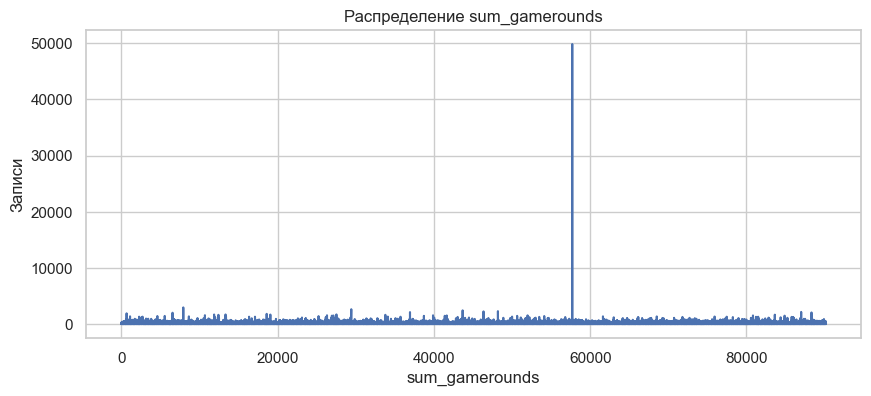

Q1= 5.0 51.0 46.0
number_gameraunds 4678325 17.0 16.0


In [7]:
#число пустых значений (пустых значений нет)
#print(df.isnull().sum())

#user_id  version  sum_gamerounds  retention_1  retention_7
#print(df.head(), df.info())

#доля пользователей в группе
#.shape берет размерность табл (2,3), где 2 - строки, а shape[0] - берет только строки
number_a=df[df['version']=='gate_30'].shape[0]*100.0/df.count()
number_b=df[df['version']=='gate_40'].shape[0]*100.0/df.count()
print("number_a",number_a)
print("number_b",number_b)

# выбросы для sum_gamerounds
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(df['sum_gamerounds'])
#plt.xlim(57700,57705) - норм распред
plt.title('Распределение sum_gamerounds')
plt.xlabel('sum_gamerounds')
plt.ylabel('Записи')
plt.show()

Q1=df['sum_gamerounds'].quantile(0.25)
Q3=df['sum_gamerounds'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['sum_gamerounds']<Q1 -1.5*IQR)|(df['sum_gamerounds']>Q3 +1.5*IQR)]
print('Q1=',Q1,Q3,IQR)
#print(f"Convertion p-value:{p_value:.4f}")

#общее число раундов и медианное по группам
number_gameraunds=df['sum_gamerounds'].sum()
number_gameraunds_a=df[df['version']=='gate_30']['sum_gamerounds'].median()
number_gameraunds_b=df[df['version']=='gate_40']['sum_gamerounds'].median()
#17.0 16.0
print('number_gameraunds',number_gameraunds, number_gameraunds_a,number_gameraunds_b)

средняя конверсия для 1 дня = version
gate_30    0.448188
gate_40    0.442283
Name: retention_1, dtype: float64 /nсредняя конверсия для 7 дня = version
gate_30    0.190201
gate_40    0.182000
Name: retention_7, dtype: float64


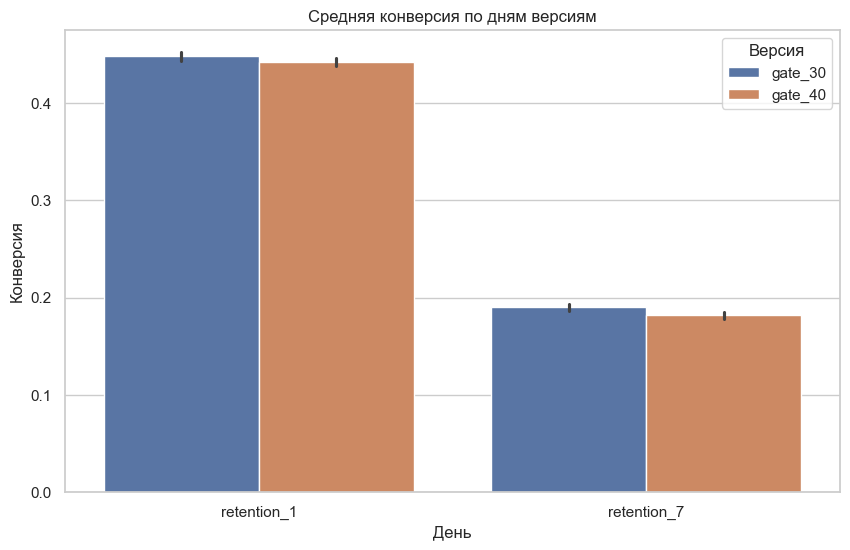

In [ ]:
#средняя консерсия по версиям для 1 и 7 дней
conversion_rates1=df.groupby('version')['retention_1'].mean()
conversion_rates7=df.groupby('version')['retention_7'].mean()
print ('средняя конверсия для 1 дня =', conversion_rates1, "/nсредняя конверсия для 7 дня =",conversion_rates7 )

# визуализация распределения конверсии
    # Подготовка данных - чтобы было 4 столбца на 1 графике
df_melted = df.melt(
    id_vars=['version'], # что оставляем
    value_vars=['retention_1', 'retention_7'], # что переносим из столбцов в аргементы строк
    var_name='day', # название колонки с именами
    value_name='conversion' # название колонки со значениями
)

    # График с grouped bars
plt.figure(figsize=(10, 6))
sns.barplot(x='day', y='conversion', hue='version', data=df_melted, estimator=np.mean)
plt.title('Средняя конверсия по дням версиям')
plt.ylabel('Конверсия')
plt.xlabel('День')
plt.legend(title='Версия')
plt.show()


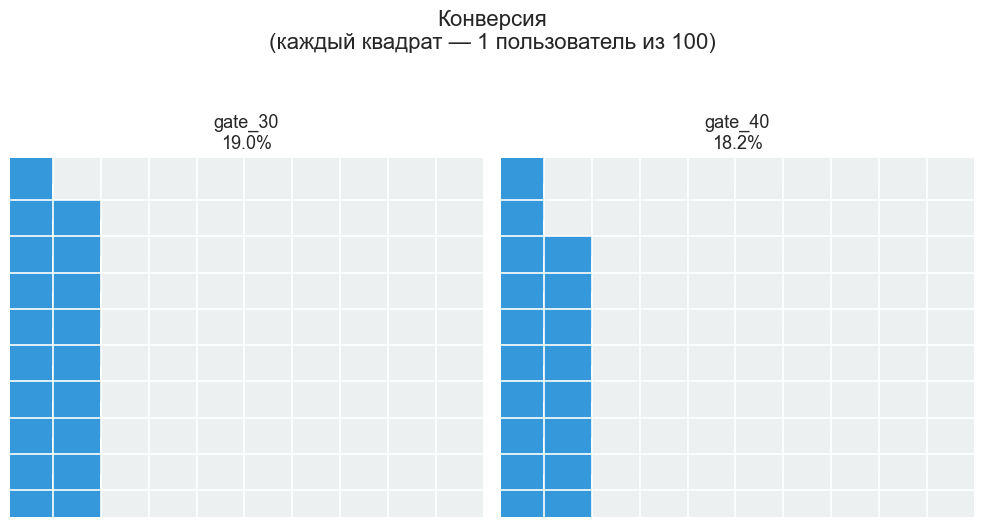

In [9]:
# покажем на графике с квадратами конверсию для 7 дня по версиям

fig,(ax1,ax2) = plt.subplots(1,2,figsize = (10,5))
# Считаем retention (доли от 0 до 1)
ret_1_30 = df[df['version']=='gate_30']['retention_7'].mean()  # 0.448
ret_1_40 = df[df['version']=='gate_40']['retention_7'].mean()  # 0.442

# Передаем retention (правильный тип данных)
plot_conversion_squares(ret_1_30, "gate_30", ax1)
plot_conversion_squares(ret_1_40, "gate_40", ax2)

plt.suptitle("Конверсия\n(каждый квадрат — 1 пользователь из 100)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

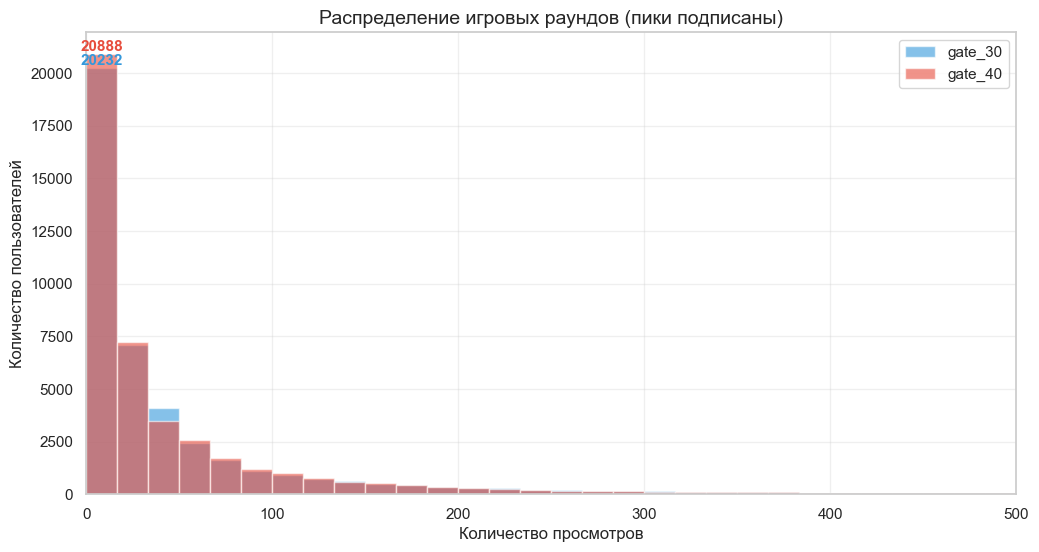

In [ ]:
#распределение sum_gamerounds с подписью пиков
plt.figure(figsize=(12, 6))
data_30 = df.query('version=="gate_30" & sum_gamerounds!=0').sum_gamerounds
data_40 = df.query('version=="gate_40" & sum_gamerounds!=0').sum_gamerounds
counts_30, bins_30, patches_30 = plt.hist(
    data_30, alpha=0.6, label="gate_30", bins=30, range=(0, 500), color='#3498db'
)

"""counts_40 - массив высот
bins_40 - границы интервалов
patches_40 - объекты столбцов"""
counts_40, bins_40, patches_40 = plt.hist(
    data_40, alpha=0.6, label="gate_40", bins=30, range=(0, 500), color='#e74c3c'
)
max_30_idx = np.argmax(counts_30)  # находим индекс самого высокого столбца
max_30_value = counts_30[max_30_idx]  # берем  элемент по индексу
max_30_center = bins_30[max_30_idx] + (bins_30[1] - bins_30[0]) / 2  # центр самого высокого столбца

plt.text(max_30_center, max_30_value + 20, # координаты подписи
         f'{int(max_30_value)}', 
         ha='center', va='bottom', # горизонт и вертик выравнивание
         fontsize=11, color='#3498db', weight='bold') # размер,цвет, жирность

# Максимум для gate_40
max_40_idx = np.argmax(counts_40)
max_40_value = counts_40[max_40_idx]
max_40_center = bins_40[max_40_idx] + (bins_40[1] - bins_40[0]) / 2

plt.text(max_40_center, max_40_value + 20, 
         f'{int(max_40_value)}', 
         ha='center', va='bottom', 
         fontsize=11, color='#e74c3c', weight='bold')

# Ограничения и подписи
plt.xlim(0, 500)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xlabel('Количество просмотров', fontsize=12)
plt.legend(fontsize=11)
plt.title('Распределение игровых раундов (пики подписаны)', fontsize=14)
plt.grid(alpha=0.3)
plt.show()

In [11]:
df.groupby('version')\
    .agg(avg_count=('sum_gamerounds','mean'))


df.query('version=="gate_30"').retention_7.value_counts(normalize=1)



retention_7
False    0.809799
True     0.190201
Name: proportion, dtype: float64

In [12]:
#статистика

alpha = 0.05

contingency = pd.crosstab(df['version'], df['retention_7'])
chi2, p_chi, dof, expected = chi2_contingency(contingency)

print("\nХи-квадрат тест: Конверсия в просмотр (если ретеншен = 1 , то просмотр был")
print(contingency)
print(f"p-value = {p_chi:.2e}")

if p_chi<alpha:
  print("Разница статистически значима")
else:
  print("Разница статистически не значима")



Хи-квадрат тест: Конверсия в просмотр (если ретеншен = 1 , то просмотр был
retention_7  False  True 
version                  
gate_30      36198   8502
gate_40      37210   8279
p-value = 1.60e-03
Разница статистически значима


In [13]:
views_a = df[df['version']=='gate_30']['sum_gamerounds']
views_b = df[df['version']=='gate_40']['sum_gamerounds']

stat, p = mannwhitneyu(views_a, views_b, alternative='two-sided')

print("\nМаннаУитнни-тест: Среднее количество просмотров")
print(f"A: {views_a.mean():.2f}, B: {views_b.mean():.2f}")
print(f"p-value = {p:.3f}")

print(f'Рост: {views_b.mean()/views_a.mean() - 1:.2%}')

if p<alpha:
  print("Разница статистически значима")
else:
  print("Разница статистически не значима")


МаннаУитнни-тест: Среднее количество просмотров
A: 52.46, B: 51.30
p-value = 0.050
Рост: -2.21%
Разница статистически не значима


In [14]:
print(f'Всего пользователей за период: {df.user_id.nunique()}')
print(f'Доля вернувшихся на 7 день в gate_30 группе: {round(df.query("version=='gate_30'").retention_7.mean()*100,1)}%')
print(f'Доля вернувшихся на 7 день в gate_40 группе: {round(df.query("version=='gate_40'").retention_7.mean()*100,1)}%')
print(f'Раньше: {df.user_id.nunique()*df.query("version=='gate_30'").retention_7.mean()}')
print(f'После: {df.user_id.nunique()*df.query("version=='gate_40'").retention_7.mean()}')
print(f'Изменение в пользователях: {df.user_id.nunique()*df.query("version=='gate_40'").retention_7.mean() - df.user_id.nunique()*df.query("version=='gate_30'").retention_7.mean()} ')


print(f'Раньше на 100к пользователей было: {df.user_id.nunique()*df.query("version=='gate_30'").sum_gamerounds.mean()}')
print(f'Теперь на 100к пользователей будет: {df.user_id.nunique()*df.query("version=='gate_40'").sum_gamerounds.mean()}')
if df.user_id.nunique()*df.query("version=='gate_40'").sum_gamerounds.mean() - df.user_id.nunique()*df.query("version=='gate_30'").sum_gamerounds.mean()>=0:
    print('Рост на:',{df.user_id.nunique()*df.query("version=='gate_40'").sum_gamerounds.mean() - df.user_id.nunique()*df.query("version=='gate_30'").sum_gamerounds.mean()})
else:
    print(f'Падение на:{df.user_id.nunique()*df.query("version=='gate_40'").sum_gamerounds.mean() - df.user_id.nunique()*df.query("version=='gate_30'").sum_gamerounds.mean()}')


Всего пользователей за период: 90189
Доля вернувшихся на 7 день в gate_30 группе: 19.0%
Доля вернувшихся на 7 день в gate_40 группе: 18.2%
Раньше: 17154.0688590604
После: 16414.401965310295
Изменение в пользователях: -739.6668937501054 
Раньше на 100к пользователей было: 4730977.992281879
Теперь на 100к пользователей будет: 4626585.26610829
Падение на:-104392.726173589
